<a href="https://colab.research.google.com/github/buiswrld/eos-inference/blob/main/Neutron_Star_EOS_Phase_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neutron Star EOS, Phase 2: TOV Physics + Flow Matching
Full pipeline: spectral EOS -> TOV solver -> synthetic catalog generation ->
type-specific encoders -> set aggregation -> flow matching posterior decoder.

In [ ]:
import os, math, random, pickle
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/ns_eos_project'

for f in ['data/raw','data/processed','models','figures','checkpoints','notebooks']:
    os.makedirs(os.path.join(PROJECT_ROOT, f), exist_ok=True)

DATA_RAW       = os.path.join(PROJECT_ROOT, 'data/raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
MODELS         = os.path.join(PROJECT_ROOT, 'models')
FIGURES        = os.path.join(PROJECT_ROOT, 'figures')
CHECKPOINTS    = os.path.join(PROJECT_ROOT, 'checkpoints')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def move_to_device(batch, dev):
    return {k: v.to(dev) if torch.is_tensor(v) else v for k, v in batch.items()}

Mounted at /content/drive
Device: cuda


---
## Section 2 — Physical Constants & EOS Prior

In [ ]:
# CGS constants
G_CGS = 6.67430e-8
C_LIGHT = 2.99792458e10
M_SUN_CGS = 1.98892e33
KM_CM = 1.0e5

# Unit conversions
MEV_FM3_TO_CGS = 1.6022e33
CGS_TO_MEV_FM3 = 1.0 / MEV_FM3_TO_CGS

# Nuclear saturation
RHO_NUC = 2.8e14
EPS_NUC_MEV = RHO_NUC * C_LIGHT**2 * CGS_TO_MEV_FM3
P_NUC_MEV = 3.0

# Low-density crust polytrope
GAMMA_CRUST = 1.35
K_CRUST = P_NUC_MEV / (EPS_NUC_MEV ** GAMMA_CRUST)
P_MAX_MEV = 1500.0

# EOS prior bounds
PRIOR_BOUNDS = {
    'gamma0': (0.2, 2.0),
    'gamma1': (-1.6, 1.7),
    'gamma2': (-0.6, 0.6),
    'gamma3': (-0.02, 0.02),
}

# Target normalization
theta_mean = torch.tensor([1.10, 0.05, 0.00, 0.000], device=device)
theta_std  = torch.tensor([0.52, 0.96, 0.35, 0.012], device=device)

def normalize_theta(theta):
    return (theta - theta_mean) / theta_std

def denormalize_theta(theta_norm):
    return theta_norm * theta_std + theta_mean

print(f'Nuclear saturation eps ~ {EPS_NUC_MEV:.1f} MeV/fm^3')

Nuclear saturation eps ~ 157.1 MeV/fm^3


---
## Section 3 — Spectral EOS & TOV Solver

In [ ]:
LOG_P_NUC = np.log(P_NUC_MEV)
LOG_P_MAX = np.log(P_MAX_MEV)
LOG_P_RANGE = LOG_P_MAX - LOG_P_NUC

def spectral_gamma(P_mev, gc):
    """Adiabatic index from spectral coefficients."""
    x = np.clip((np.log(P_mev) - LOG_P_NUC) / LOG_P_RANGE, 0, 1)
    return np.exp(gc[0] + gc[1]*x + gc[2]*x**2 + gc[3]*x**3)

def build_eos(gc, n_pts=300):
    """Build interpolated eps(logP) and gamma(logP) from spectral coeffs."""
    log_P = np.linspace(LOG_P_NUC, LOG_P_MAX, n_pts)
    P = np.exp(log_P)
    eps = np.zeros(n_pts)
    eps[0] = EPS_NUC_MEV
    h = log_P[1] - log_P[0]
    for i in range(n_pts - 1):
        Pi, ei = P[i], eps[i]
        Gi = spectral_gamma(Pi, gc)
        k1 = (ei + Pi) / Gi
        Ph = np.exp(log_P[i] + h/2)
        Gh = spectral_gamma(Ph, gc)
        k2 = (ei + h/2*k1 + Ph) / Gh
        k3 = (ei + h/2*k2 + Ph) / Gh
        Pn = P[i+1]
        Gn = spectral_gamma(Pn, gc)
        k4 = (ei + h*k3 + Pn) / Gn
        eps[i+1] = ei + h/6*(k1 + 2*k2 + 2*k3 + k4)
    # Low-density crust
    n_low = 50
    P_low = np.logspace(-8, np.log10(P_NUC_MEV), n_low, endpoint=False)
    eps_low = (P_low / K_CRUST) ** (1.0 / GAMMA_CRUST)
    P_all = np.concatenate([P_low, P])
    eps_all = np.concatenate([eps_low, eps])
    gam_all = np.concatenate([np.full(n_low, GAMMA_CRUST),
                              np.array([spectral_gamma(p, gc) for p in P])])
    ei = interp1d(np.log(P_all), eps_all, kind='cubic',
                  bounds_error=False, fill_value='extrapolate')
    gi = interp1d(np.log(P_all), gam_all, kind='cubic',
                  bounds_error=False, fill_value='extrapolate')
    return ei, gi

P_MIN_CGS = 1e-4 * MEV_FM3_TO_CGS

def solve_tov_single(Pc_mev, eps_i, gam_i):
    """Integrate TOV + tidal perturbation. Returns (M_sun, R_km, Lambda)."""
    Pc_cgs = Pc_mev * MEV_FM3_TO_CGS
    ec_cgs = eps_i(np.log(Pc_mev)) * MEV_FM3_TO_CGS
    r0 = 100.0
    m0 = (4.0/3.0) * np.pi * r0**3 * ec_cgs / C_LIGHT**2
    def rhs(r, s):
        P, m, y = s
        if P <= P_MIN_CGS or r < 1.0:
            return [0.0, 0.0, 0.0]
        Pm = max(P * CGS_TO_MEV_FM3, 1e-20)
        eps = eps_i(np.log(Pm)) * MEV_FM3_TO_CGS
        gam = max(gam_i(np.log(Pm)), 1.01)
        cs2 = np.clip(gam * P / (eps + P), 1e-6, 0.999)
        beta = 2*G_CGS*m / (r*C_LIGHT**2)
        if beta >= 0.99:
            return [0.0, 0.0, 0.0]
        fac = 1.0 - beta
        A = m + 4*np.pi*r**3*P/C_LIGHT**2
        gc2 = G_CGS / C_LIGHT**2
        dPdr = -(eps + P) * gc2 * A / (r**2 * fac)
        dmdr = 4*np.pi*r**2 * eps / C_LIGHT**2
        dnu = gc2 * A / (r**2 * fac)
        e2l = 1.0 / fac
        gc4 = G_CGS / C_LIGHT**4
        At = e2l * (1 + 4*np.pi*r**2*(P - eps)*gc4)
        Q = (4*np.pi*gc4*(5*eps + 9*P + (eps+P)/cs2)
             - 6*e2l/r**2 - dnu**2)
        dydr = (-y**2 - y*At - r**2*Q) / r
        return [dPdr, dmdr, dydr]
    def surface(r, s):
        return s[0] - P_MIN_CGS
    surface.terminal = True
    surface.direction = -1
    try:
        sol = solve_ivp(rhs, [r0, 50*KM_CM], [Pc_cgs, m0, 2.0],
                        events=surface, method='RK45',
                        rtol=1e-8, atol=1e-12, max_step=5000.0)
        if sol.t_events[0].size == 0:
            return None, None, None
        Rcm = sol.t_events[0][0]
        _, Mg, ys = sol.y_events[0][0]
        R = Rcm / KM_CM
        M = Mg / M_SUN_CGS
        if M <= 0 or R <= 0 or R > 30:
            return None, None, None
        C = G_CGS * Mg / (Rcm * C_LIGHT**2)
        num = 8/5*C**5*(1-2*C)**2*(2+2*C*(ys-1)-ys)
        den = (2*C*(6-3*ys+3*C*(5*ys-8))
               + 4*C**3*(13-11*ys+C*(3*ys-2)+2*C**2*(1+ys))
               + 3*(1-2*C)**2*(2-ys+2*C*(ys-1))*np.log(1-2*C))
        if abs(den) < 1e-30:
            return M, R, None
        k2 = num / den
        Lam = 2/3 * k2 / C**5
        if Lam < 0 or np.isnan(Lam) or np.isinf(Lam):
            return M, R, None
        return M, R, Lam
    except Exception:
        return None, None, None

def compute_mr_curve(gc, n_pc=25):
    """Compute M-R-Lambda curve for one EOS."""
    ei, gi = build_eos(gc)
    log_Pc = np.linspace(np.log(P_NUC_MEV*2), np.log(P_MAX_MEV*0.8), n_pc)
    Ms, Rs, Ls = [], [], []
    for lpc in log_Pc:
        M, R, L = solve_tov_single(np.exp(lpc), ei, gi)
        if M is not None and L is not None:
            Ms.append(M); Rs.append(R); Ls.append(L)
    if len(Ms) < 5:
        return None
    return np.array(Ms), np.array(Rs), np.array(Ls)

# Sanity test
print('Testing TOV solver with reference EOS [1,0,0,0]...')
tc = compute_mr_curve([1.0, 0.0, 0.0, 0.0])
if tc is not None:
    Ms, Rs, Ls = tc
    print(f'  M_max = {np.max(Ms):.2f} Msun at R = {Rs[np.argmax(Ms)]:.1f} km')
    idx14 = np.argmin(np.abs(Ms - 1.4))
    print(f'  M~1.4: R ~ {Rs[idx14]:.1f} km, Lambda ~ {Ls[idx14]:.0f}')
else:
    print('  WARNING: reference EOS failed!')

Testing TOV solver with reference EOS [1,0,0,0]...
  M_max = 1.92 Msun at R = 10.2 km
  M~1.4: R ~ 12.9 km, Lambda ~ 187


---
## Section 4 — Synthetic Data Generation (50k samples, cached)

In [ ]:
def sample_observations(gc, mr_curve):
    """Generate synthetic observations for one EOS."""
    Ms, Rs, Ls = mr_curve
    Mmax = np.max(Ms)
    idx = np.argmax(Ms)
    Ms_s = Ms[:idx+1] if idx > 0 else Ms
    Rs_s = Rs[:idx+1] if idx > 0 else Rs
    Ls_s = Ls[:idx+1] if idx > 0 else Ls
    if len(Ms_s) < 3:
        return None
    RofM = interp1d(Ms_s, Rs_s, kind='linear', bounds_error=False, fill_value='extrapolate')
    LofM = interp1d(Ms_s, Ls_s, kind='linear', bounds_error=False, fill_value='extrapolate')
    obs = []
    # GW events
    if random.random() < 0.8:
        for _ in range(random.randint(1, 3)):
            m1 = random.uniform(1.1, min(Mmax, 2.0))
            m2 = random.uniform(1.1, min(Mmax, 2.0))
            Mc = (m1*m2)**0.6 / (m1+m2)**0.2
            L1 = max(float(LofM(m1)), 1.0)
            L2 = max(float(LofM(m2)), 1.0)
            Lt = 16/13*((m1+12*m2)*m1**4*L1 + (m2+12*m1)*m2**4*L2)/(m1+m2)**5
            sL = max(50.0, 0.3*Lt)
            obs.append({'type':'gw','x':[Lt+random.gauss(0,sL),Mc+random.gauss(0,0.01)],'sigma':[sL,0.01]})
    # NICER
    if random.random() < 0.7:
        for _ in range(random.randint(1, 2)):
            m = random.uniform(1.2, min(Mmax, 2.2))
            R = float(RofM(m))
            sm = random.uniform(0.05, 0.15)
            sR = random.uniform(0.5, 1.5)
            obs.append({'type':'nicer','x':[m+random.gauss(0,sm),R+random.gauss(0,sR)],'sigma':[sm,sR]})
    # Pulsar
    if random.random() < 0.6:
        m = random.uniform(1.4, min(Mmax, 2.5))
        sm = random.uniform(0.01, 0.05)
        obs.append({'type':'pulsar','x':[m+random.gauss(0,sm)],'sigma':[sm]})
    if not obs:
        m1 = random.uniform(1.1, min(Mmax, 2.0))
        m2 = random.uniform(1.1, min(Mmax, 2.0))
        Mc = (m1*m2)**0.6 / (m1+m2)**0.2
        L1 = max(float(LofM(m1)), 1.0)
        L2 = max(float(LofM(m2)), 1.0)
        Lt = 16/13*((m1+12*m2)*m1**4*L1 + (m2+12*m1)*m2**4*L2)/(m1+m2)**5
        obs.append({'type':'gw','x':[Lt,Mc],'sigma':[max(50,0.3*Lt),0.01]})
    return obs

N_SAMPLES = 50000
CACHE_PATH = f'{DATA_PROCESSED}/tov_data_50k.pkl'

def generate_or_load_data():
    if os.path.exists(CACHE_PATH):
        print(f'Loading cached data from {CACHE_PATH}')
        with open(CACHE_PATH, 'rb') as f:
            data = pickle.load(f)
        print(f'  Loaded {len(data)} samples')
        return data
    print(f'Generating {N_SAMPLES} samples with TOV solver...')
    print('This takes ~1-2 hours. Results are cached for future runs.')
    data = []
    n_fail = 0
    for i in tqdm(range(N_SAMPLES * 2)):  # oversample to compensate rejections
        if len(data) >= N_SAMPLES:
            break
        gc = [random.uniform(*PRIOR_BOUNDS['gamma0']),
              random.uniform(*PRIOR_BOUNDS['gamma1']),
              random.uniform(*PRIOR_BOUNDS['gamma2']),
              random.uniform(*PRIOR_BOUNDS['gamma3'])]
        try:
            curve = compute_mr_curve(gc)
            if curve is None:
                n_fail += 1; continue
            cat = sample_observations(gc, curve)
            if cat is None:
                n_fail += 1; continue
            data.append({'theta_eos': gc, 'catalog': cat})
        except Exception:
            n_fail += 1
    print(f'  Generated {len(data)} valid samples ({n_fail} rejected)')
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(data, f)
    print(f'  Saved to {CACHE_PATH}')
    return data

all_data = generate_or_load_data()

Loading cached data from /content/drive/MyDrive/ns_eos_project/data/processed/tov_data_50k.pkl
  Loaded 50000 samples


---
## Section 5 — Dataset & Collate Function

In [ ]:
class EOSCatalogDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        theta = torch.tensor(s['theta_eos'], dtype=torch.float32)
        catalog = [{'type': o['type'].lower(),
                     'x': torch.tensor(o['x'], dtype=torch.float32),
                     'sigma': torch.tensor(o['sigma'], dtype=torch.float32)}
                    for o in s['catalog']]
        return {'theta': theta, 'catalog': catalog}

def collate_fn(batch):
    thetas = torch.stack([item['theta'] for item in batch], dim=0)
    num_catalogs = len(batch)
    grouped = {
        'gw':     {'x':[],'sigma':[],'catalog_idx':[],'dim':2},
        'nicer':  {'x':[],'sigma':[],'catalog_idx':[],'dim':2},
        'pulsar': {'x':[],'sigma':[],'catalog_idx':[],'dim':1},
    }
    for ci, item in enumerate(batch):
        for obs in item['catalog']:
            t = obs['type']
            grouped[t]['x'].append(obs['x'])
            grouped[t]['sigma'].append(obs['sigma'])
            grouped[t]['catalog_idx'].append(ci)
    output = {'theta': thetas, 'num_catalogs': num_catalogs}
    for ot, vals in grouped.items():
        if len(vals['x']) > 0:
            output[ot+'_x'] = torch.stack(vals['x'], dim=0)
            output[ot+'_sigma'] = torch.stack(vals['sigma'], dim=0)
            output[ot+'_catalog_idx'] = torch.tensor(vals['catalog_idx'], dtype=torch.long)
        else:
            d = vals['dim']
            output[ot+'_x'] = torch.empty(0, d, dtype=torch.float32)
            output[ot+'_sigma'] = torch.empty(0, d, dtype=torch.float32)
            output[ot+'_catalog_idx'] = torch.empty(0, dtype=torch.long)
    return output

print('Dataset and collate_fn defined.')

Dataset and collate_fn defined.


---
## Section 6 — Model: Type Encoders + Set Aggregator + Flow Matching

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device, dtype=t.dtype) / half)
        args = t.unsqueeze(-1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class MultiMessengerEOSModel(nn.Module):
    def __init__(self, d_embed=64, d_hidden_flow=256, time_embed_dim=32,
                 theta_dim=4, use_set_transformer=False, n_heads=4, n_attn_layers=2):
        super().__init__()
        self.d_embed = d_embed
        self.theta_dim = theta_dim
        self.use_set_transformer = use_set_transformer

        # Normalization buffers for physical values
        self.register_buffer('gw_mu_x', torch.tensor([500.0, 1.2]))
        self.register_buffer('gw_sd_x', torch.tensor([500.0, 0.2]))
        self.register_buffer('gw_mu_s', torch.tensor([150.0, 0.01]))
        self.register_buffer('gw_sd_s', torch.tensor([150.0, 0.005]))
        self.register_buffer('nicer_mu_x', torch.tensor([1.6, 12.0]))
        self.register_buffer('nicer_sd_x', torch.tensor([0.4, 2.0]))
        self.register_buffer('nicer_mu_s', torch.tensor([0.1, 1.0]))
        self.register_buffer('nicer_sd_s', torch.tensor([0.05, 0.5]))
        self.register_buffer('pulsar_mu_x', torch.tensor([2.0]))
        self.register_buffer('pulsar_sd_x', torch.tensor([0.5]))
        self.register_buffer('pulsar_mu_s', torch.tensor([0.03]))
        self.register_buffer('pulsar_sd_s', torch.tensor([0.02]))

        # Type-specific encoders
        self.gw_enc = nn.Sequential(nn.Linear(4, d_embed), nn.ReLU(),
                                    nn.Linear(d_embed, d_embed), nn.ReLU(),
                                    nn.Linear(d_embed, d_embed))
        self.nicer_enc = nn.Sequential(nn.Linear(4, d_embed), nn.ReLU(),
                                       nn.Linear(d_embed, d_embed), nn.ReLU(),
                                       nn.Linear(d_embed, d_embed))
        self.pulsar_enc = nn.Sequential(nn.Linear(2, d_embed), nn.ReLU(),
                                        nn.Linear(d_embed, d_embed), nn.ReLU(),
                                        nn.Linear(d_embed, d_embed))
        # Set Transformer (optional)
        if use_set_transformer:
            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_embed, nhead=n_heads, dim_feedforward=d_embed*4,
                batch_first=True, dropout=0.1)
            self.set_tf = nn.TransformerEncoder(enc_layer, num_layers=n_attn_layers)
            self.pool_q = nn.Parameter(torch.randn(1, 1, d_embed) * 0.02)
            self.pool_attn = nn.MultiheadAttention(d_embed, n_heads, batch_first=True)
            self.pool_norm = nn.LayerNorm(d_embed)
        # Flow matching velocity field
        self.time_emb = SinusoidalTimeEmbedding(time_embed_dim)
        fin = theta_dim + time_embed_dim + d_embed
        self.vel_net = nn.Sequential(
            nn.Linear(fin, d_hidden_flow), nn.GELU(),
            nn.Linear(d_hidden_flow, d_hidden_flow), nn.GELU(),
            nn.Linear(d_hidden_flow, d_hidden_flow), nn.GELU(),
            nn.Linear(d_hidden_flow, theta_dim))

    def _normalize_features(self, ot, x, sigma):
        if ot == 'gw':
            x = (x - self.gw_mu_x) / self.gw_sd_x
            sigma = (sigma - self.gw_mu_s) / self.gw_sd_s
        elif ot == 'nicer':
            x = (x - self.nicer_mu_x) / self.nicer_sd_x
            sigma = (sigma - self.nicer_mu_s) / self.nicer_sd_s
        elif ot == 'pulsar':
            x = (x - self.pulsar_mu_x) / self.pulsar_sd_x
            sigma = (sigma - self.pulsar_mu_s) / self.pulsar_sd_s
        return x, sigma

    def _get_encoders(self):
        return [('gw', self.gw_enc), ('nicer', self.nicer_enc), ('pulsar', self.pulsar_enc)]

    def _deepsets_aggregate(self, batch, dev, B):
        acc = torch.zeros(B, self.d_embed, device=dev)
        cnt = torch.zeros(B, 1, device=dev)
        for ot, enc in self._get_encoders():
            x = batch[ot+'_x']
            sigma = batch[ot+'_sigma']
            idx = batch[ot+'_catalog_idx']
            if x.shape[0] == 0:
                continue
            x, sigma = self._normalize_features(ot, x, sigma)
            emb = enc(torch.cat([x, sigma], dim=-1))
            acc.scatter_add_(0, idx.unsqueeze(1).expand_as(emb), emb)
            cnt.scatter_add_(0, idx.unsqueeze(1), torch.ones(x.shape[0], 1, device=dev))
        return acc / cnt.clamp(min=1)

    def _set_transformer_aggregate(self, batch, dev, B):
        all_embs, all_idx = [], []
        for ot, enc in self._get_encoders():
            x = batch[ot+'_x']
            sigma = batch[ot+'_sigma']
            idx = batch[ot+'_catalog_idx']
            if x.shape[0] == 0:
                continue
            x, sigma = self._normalize_features(ot, x, sigma)
            all_embs.append(enc(torch.cat([x, sigma], dim=-1)))
            all_idx.append(idx)
        if not all_embs:
            return torch.zeros(B, self.d_embed, device=dev)
        all_embs = torch.cat(all_embs, 0)
        all_idx = torch.cat(all_idx, 0)
        max_len = max((all_idx == i).sum().item() for i in range(B))
        padded = torch.zeros(B, max_len, self.d_embed, device=dev)
        mask = torch.zeros(B, max_len, dtype=torch.bool, device=dev)
        for i in range(B):
            sel = (all_idx == i)
            e = all_embs[sel]
            n = e.shape[0]
            padded[i, :n] = e
            mask[i, :n] = True
        x = self.set_tf(padded, src_key_padding_mask=~mask)
        q = self.pool_q.expand(B, -1, -1)
        pooled, _ = self.pool_attn(q, x, x, key_padding_mask=~mask)
        return self.pool_norm(pooled + q).squeeze(1)

    def encode_and_aggregate(self, batch):
        dev = next(self.parameters()).device
        B = batch['num_catalogs']
        if self.use_set_transformer:
            return self._set_transformer_aggregate(batch, dev, B)
        return self._deepsets_aggregate(batch, dev, B)

    def compute_loss(self, batch, theta_norm):
        """Flow matching training loss."""
        summary = self.encode_and_aggregate(batch)
        B = summary.shape[0]
        dev = summary.device
        t = torch.rand(B, 1, device=dev)
        z = torch.randn(B, self.theta_dim, device=dev)
        x_t = (1 - t) * z + t * theta_norm
        v_target = theta_norm - z
        t_emb = self.time_emb(t.squeeze(-1))
        inp = torch.cat([x_t, t_emb, summary], dim=-1)
        v_pred = self.vel_net(inp)
        return F.mse_loss(v_pred, v_target)

    @torch.no_grad()
    def sample(self, batch, n_samples=1000, n_steps=100):
        """Generate posterior samples via Euler ODE integration."""
        summary = self.encode_and_aggregate(batch)
        B = summary.shape[0]
        dev = summary.device
        s_rep = summary.unsqueeze(1).expand(B, n_samples, -1).reshape(B*n_samples, -1)
        z = torch.randn(B*n_samples, self.theta_dim, device=dev)
        dt = 1.0 / n_steps
        for step in range(n_steps):
            tv = torch.full((z.shape[0],), step*dt, device=dev)
            t_emb = self.time_emb(tv)
            inp = torch.cat([z, t_emb, s_rep], dim=-1)
            z = z + self.vel_net(inp) * dt
        return z.reshape(B, n_samples, self.theta_dim)

# Quick summary
_m = MultiMessengerEOSModel()
print(f'Model params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m

Model params: 184,260


---
## Section 7 — Training

In [ ]:
random.seed(42)
torch.manual_seed(42)

full_dataset = EOSCatalogDataset(all_data)
N = len(full_dataset)
N_TRAIN = int(0.70 * N)
N_VAL = int(0.15 * N)
N_TEST = N - N_TRAIN - N_VAL
train_ds, val_ds, test_ds = random_split(
    full_dataset, [N_TRAIN, N_VAL, N_TEST],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

LR = 3e-4
WD = 1e-4
NUM_EPOCHS = 200
LOG_EVERY = 20

model = MultiMessengerEOSModel(use_set_transformer=False).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

train_losses, val_losses = [], []
print(f'\nTraining for {NUM_EPOCHS} epochs | device: {device}')
print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>12}')
print('-' * 34)

for epoch in range(NUM_EPOCHS):
    model.train()
    tt, ts = 0.0, 0
    for batch in train_loader:
        batch = move_to_device(batch, device)
        theta_norm = normalize_theta(batch['theta'])
        loss = model.compute_loss(batch, theta_norm)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        tt += loss.item(); ts += 1
    train_losses.append(tt / ts)

    model.eval()
    vt, vs = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch = move_to_device(batch, device)
            theta_norm = normalize_theta(batch['theta'])
            loss = model.compute_loss(batch, theta_norm)
            vt += loss.item(); vs += 1
    val_losses.append(vt / vs)

    if epoch % LOG_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        print(f'{epoch:>6}  {train_losses[-1]:>12.6f}  {val_losses[-1]:>12.6f}')

ckpt = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
}
torch.save(ckpt, f'{CHECKPOINTS}/phase2_flow_matching.pt')
print(f'\nCheckpoint saved to {CHECKPOINTS}/phase2_flow_matching.pt')
print(f'Final Training Loss:   {train_losses[-1]:.6f}')
print(f'Final Validation Loss: {val_losses[-1]:.6f}')

Train: 40000, Val: 10000
Training for 200 epochs | device: cuda
 Epoch       Train         Val
------------------------------
     0    1.646050    1.550831
    20    1.139482    1.142751
    40    1.128938    1.118005
    60    1.129056    1.133062
    80    1.119941    1.106540
   100    1.102067    1.125641
   120    1.109873    1.097575
   140    1.106202    1.115461
   160    1.101464    1.110710
   180    1.100812    1.105291
   199    1.099147    1.110867
Checkpoint saved.


---
## Section 8 — Loss Curves, Posterior Evaluation & Permutation Test

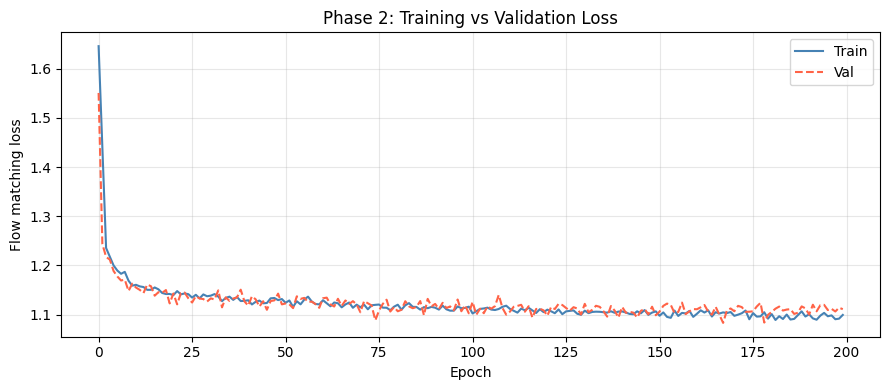

Final train: 1.099147, val: 1.110867


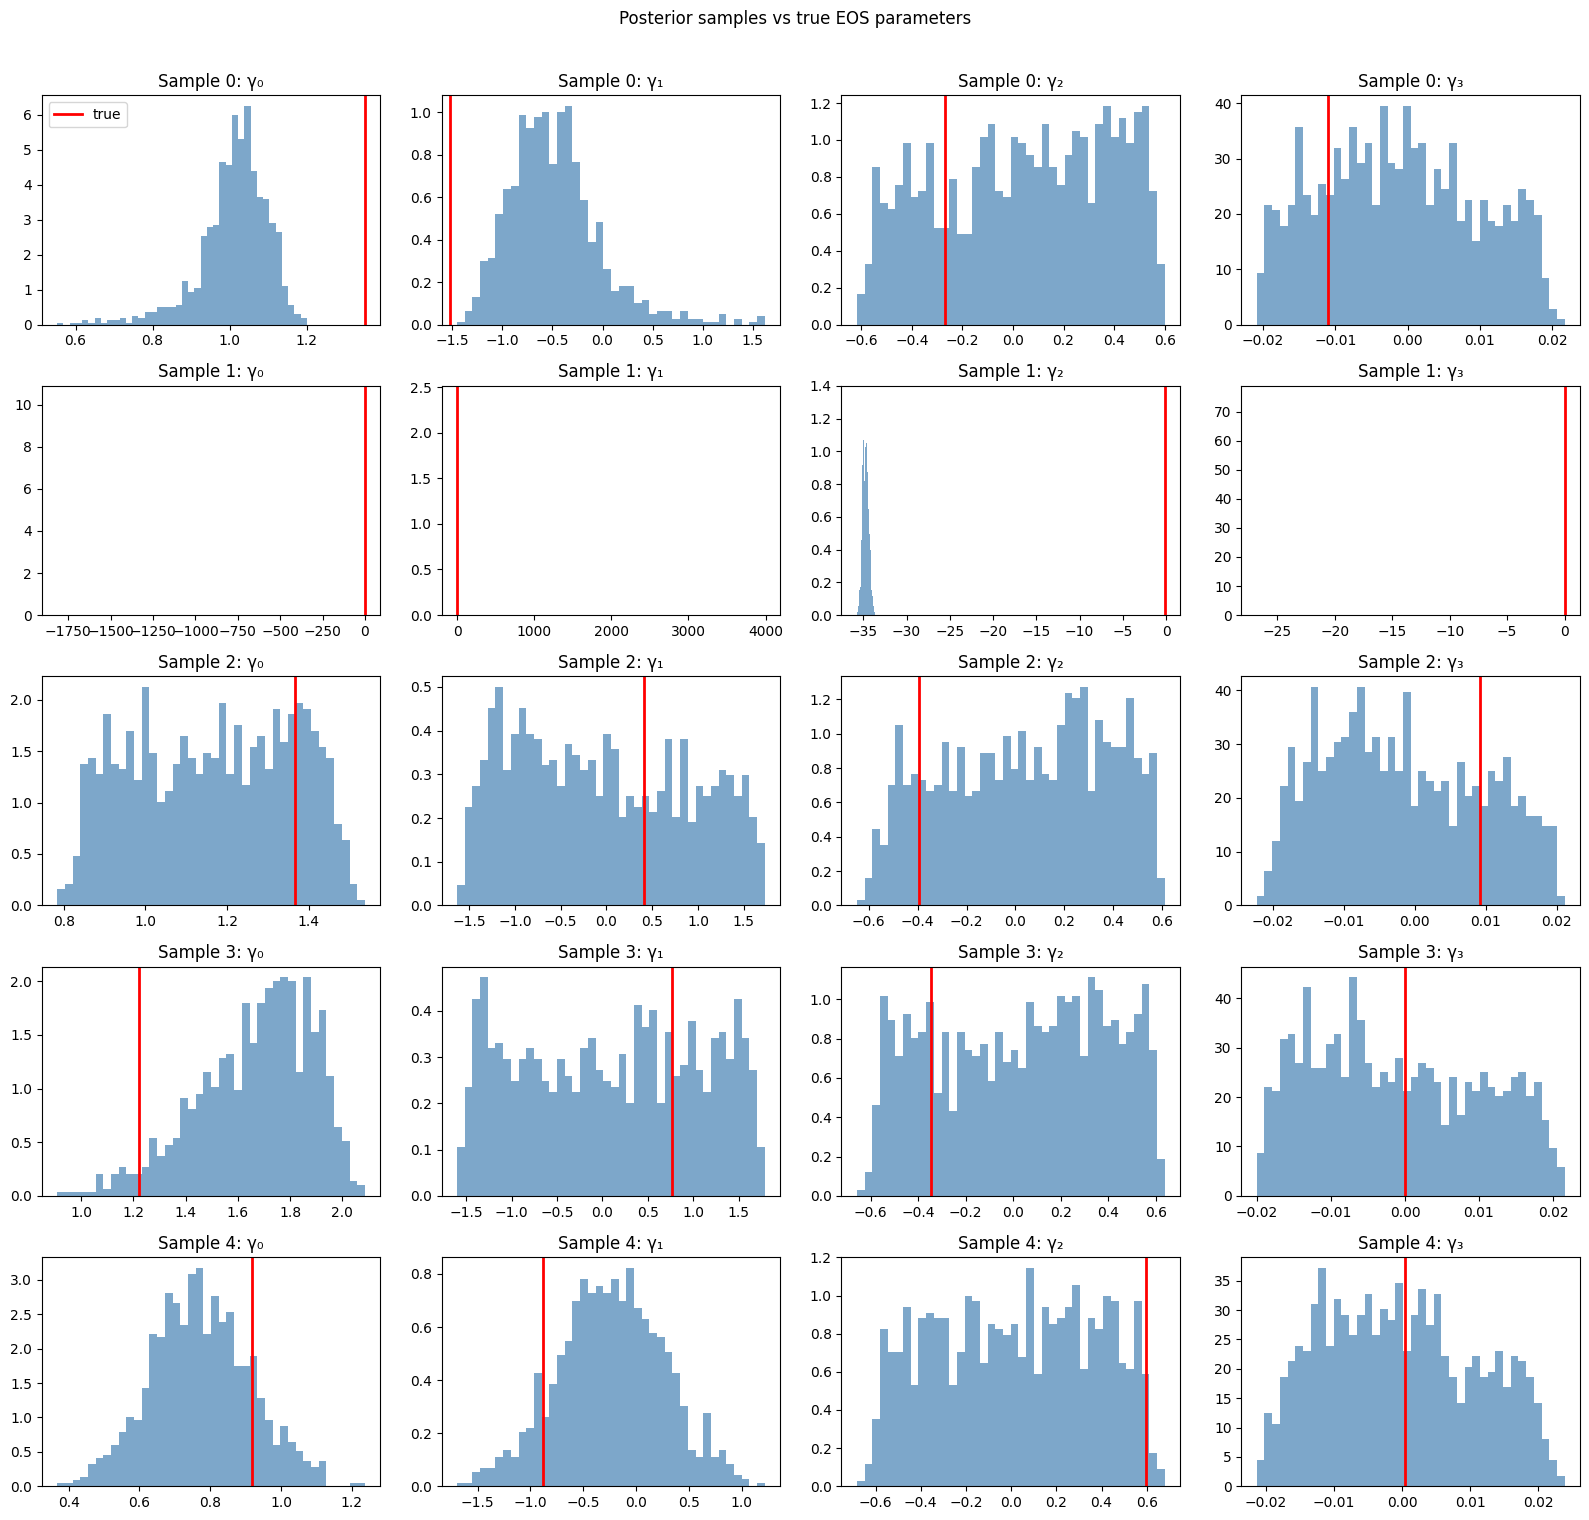


--- Permutation Invariance Test ---
  Shuffle 1: max |dev| = 2.98e-08
  Shuffle 2: max |dev| = 2.98e-08
  Shuffle 3: max |dev| = 0.00e+00
  Shuffle 4: max |dev| = 2.98e-08
  Shuffle 5: max |dev| = 2.98e-08

Max deviation: 2.98e-08
PASS: Permutation invariance confirmed.


In [ ]:
# ── Loss curves ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train', color='steelblue', lw=1.5)
ax.plot(val_losses, label='Val', color='tomato', lw=1.5, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Flow matching loss')
ax.set_title('Phase 2: Training vs Validation Loss')
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig(f'{FIGURES}/loss_curve_phase2.png', dpi=150)
plt.show()
print(f'Final train: {train_losses[-1]:.6f}, val: {val_losses[-1]:.6f}')

# ── Posterior evaluation ──────────────────────────────────────────────────────
model.eval()
param_names = ['\u03b3\u2080', '\u03b3\u2081', '\u03b3\u2082', '\u03b3\u2083']
N_TEST = 5
N_POST = 1000

# Generate fresh test samples
test_samples = []
while len(test_samples) < N_TEST:
    gc = [random.uniform(*PRIOR_BOUNDS['gamma0']),
          random.uniform(*PRIOR_BOUNDS['gamma1']),
          random.uniform(*PRIOR_BOUNDS['gamma2']),
          random.uniform(*PRIOR_BOUNDS['gamma3'])]
    curve = compute_mr_curve(gc)
    if curve is None: continue
    cat = sample_observations(gc, curve)
    if cat is None: continue
    test_samples.append({'theta_eos': gc, 'catalog': cat})

fig, axes = plt.subplots(N_TEST, 4, figsize=(16, 3*N_TEST))
for si, sample in enumerate(test_samples):
    ds = EOSCatalogDataset([sample])
    loader = DataLoader(ds, batch_size=1, collate_fn=collate_fn)
    batch = move_to_device(next(iter(loader)), device)
    post_norm = model.sample(batch, n_samples=N_POST, n_steps=100)
    post = denormalize_theta(post_norm.squeeze(0)).cpu().numpy()
    true_theta = sample['theta_eos']
    for pi in range(4):
        ax = axes[si, pi] if N_TEST > 1 else axes[pi]
        ax.hist(post[:, pi], bins=40, density=True, alpha=0.7, color='steelblue')
        ax.axvline(true_theta[pi], color='red', lw=2, label='true')
        ax.set_title(f'Sample {si}: {param_names[pi]}')
        if si == 0 and pi == 0:
            ax.legend()
fig.suptitle('Posterior samples vs true EOS parameters', y=1.01)
fig.tight_layout()
fig.savefig(f'{FIGURES}/posteriors_phase2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Permutation invariance test ───────────────────────────────────────────────
print('\n--- Permutation Invariance Test ---')
perm_sample = None
for s in all_data:
    if len(s['catalog']) >= 3:
        perm_sample = s; break
assert perm_sample is not None

def run_single(sample):
    ds = EOSCatalogDataset([sample])
    loader = DataLoader(ds, batch_size=1, collate_fn=collate_fn)
    batch = move_to_device(next(iter(loader)), device)
    return model.encode_and_aggregate(batch).cpu()

with torch.no_grad():
    pred_orig = run_single(perm_sample)
    max_dev = 0.0
    for si in range(5):
        shuffled = perm_sample['catalog'].copy()
        random.shuffle(shuffled)
        pred_s = run_single({'theta_eos': perm_sample['theta_eos'], 'catalog': shuffled})
        dev = (pred_s - pred_orig).abs().max().item()
        max_dev = max(max_dev, dev)
        print(f'  Shuffle {si+1}: max |dev| = {dev:.2e}')

print(f'\nMax deviation: {max_dev:.2e}')
if max_dev < 1e-4:
    print('PASS: Permutation invariance confirmed.')
else:
    print('FAIL: Unexpected permutation sensitivity!')

---
## Section 8b — Test Set Evaluation

In [ ]:
model.eval()
param_names = ['θ_0 (γ₀)', 'θ_1 (γ₁)', 'θ_2 (γ₂)', 'θ_3 (γ₃)']

test_loss_total, test_steps = 0.0, 0
all_preds = []
all_trues = []

with torch.no_grad():
    for batch in test_loader:
        batch = move_to_device(batch, device)
        theta_norm = normalize_theta(batch['theta'])
        loss = model.compute_loss(batch, theta_norm)
        test_loss_total += loss.item()
        test_steps += 1

    for batch in test_loader:
        batch = move_to_device(batch, device)
        theta_true = batch['theta']
        post_norm = model.sample(batch, n_samples=200, n_steps=50)
        post_mean_norm = post_norm.mean(dim=1)
        post_mean = denormalize_theta(post_mean_norm)
        all_preds.append(post_mean.cpu())
        all_trues.append(theta_true.cpu())

test_loss = test_loss_total / test_steps
all_preds = torch.cat(all_preds, dim=0)
all_trues = torch.cat(all_trues, dim=0)

mae_per_param = (all_preds - all_trues).abs().mean(dim=0)
mse_per_param = ((all_preds - all_trues) ** 2).mean(dim=0)

print('=' * 60)
print('         TEST SET EVALUATION RESULTS')
print('=' * 60)
print(f'\n  Test Loss (flow matching): {test_loss:.6f}')
print(f'\n  --- Mean Absolute Error (MAE) per parameter ---')
for i, name in enumerate(param_names):
    print(f'    {name} MAE: {mae_per_param[i]:.6f}')
print(f'\n  --- Mean Squared Error (MSE) per parameter ---')
for i, name in enumerate(param_names):
    print(f'    {name} MSE: {mse_per_param[i]:.6f}')
print('\n' + '=' * 60)
print(f'  Total test samples: {len(all_trues)}')
print(f'  Overall MAE: {mae_per_param.mean():.6f}')
print(f'  Overall MSE: {mse_per_param.mean():.6f}')
print('=' * 60)

---
## Section 9 — Overfit Test & Variable Catalog-Size Test

--- Overfit Test (20 Samples) ---
Initial loss: 2.4441 | Final loss (epoch 500): 0.3884
FAIL: Model cannot overfit. Look for bugs in data flow or gradients.


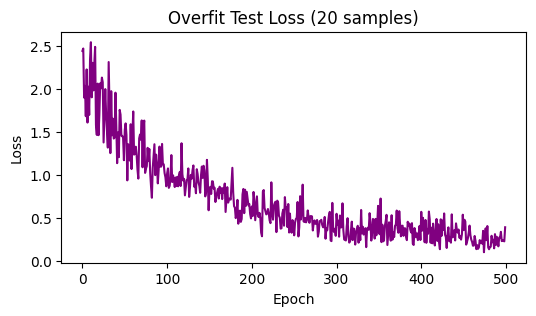


--- Variable Catalog-Size Test ---
Catalog Size N= 1 | Average Loss: 1.1370
Catalog Size N= 3 | Average Loss: 1.2230
Catalog Size N= 5 | Average Loss: 1.1100


In [ ]:
# ── 1. Overfit Test (Train on 20 examples) ────────────────────────────────────
print('--- Overfit Test (20 Samples) ---')
overfit_data = all_data[:20]
of_ds = EOSCatalogDataset(overfit_data)
of_loader = DataLoader(of_ds, batch_size=20, collate_fn=collate_fn)
of_model = MultiMessengerEOSModel(use_set_transformer=False).to(device)
of_opt = torch.optim.AdamW(of_model.parameters(), lr=1e-3) # higher LR for fast overfit
of_losses = []
for ep in range(500):
    of_model.train()
    batch = move_to_device(next(iter(of_loader)), device)
    tnorm = normalize_theta(batch['theta'])
    loss = of_model.compute_loss(batch, tnorm)
    of_opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(of_model.parameters(), 1.0)
    of_opt.step()
    of_losses.append(loss.item())

print(f'Initial loss: {of_losses[0]:.4f} | Final loss (epoch 500): {of_losses[-1]:.4f}')
if of_losses[-1] < 0.1:
    print('PASS: Model successfully overfits small dataset (learning is stable).')
else:
    print('FAIL: Model cannot overfit. Look for bugs in data flow or gradients.')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(of_losses, color='purple')
ax.set_title('Overfit Test Loss (20 samples)')
ax.set_ylabel('Loss'); ax.set_xlabel('Epoch')
plt.show()

# ── 2. Variable Catalog-Size Test ─────────────────────────────────────────────
print('\n--- Variable Catalog-Size Test ---')
sizes_to_test = [1, 3, 5, 10]
model.eval()
cat_results = []

with torch.no_grad():
    for N in sizes_to_test:
        # Filter out 50 samples that have exactly N observations, or truncate larger ones
        filtered_samples = []
        for s in all_data[-5000:]:
            if len(filtered_samples) == 50:
                break
            if len(s['catalog']) >= N:
                # Truncate to N
                new_s = {'theta_eos': s['theta_eos'], 'catalog': s['catalog'][:N]}
                filtered_samples.append(new_s)
        if len(filtered_samples) < 50:
            continue

        v_ds = EOSCatalogDataset(filtered_samples)
        v_loader = DataLoader(v_ds, batch_size=50, collate_fn=collate_fn)
        batch = move_to_device(next(iter(v_loader)), device)
        tnorm = normalize_theta(batch['theta'])
        loss = model.compute_loss(batch, tnorm).item()
        cat_results.append((N, loss))
        print(f'Catalog Size N={N:>2} | Average Loss: {loss:.4f}')
